# 04 · Selectors: try an alternative

## Learning objectives

- Implement fallback and priority.
- Contrast selector and sequence propagation.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A **selector** tries children from left to right until one does not fail. It returns SUCCESS
or RUNNING immediately, and fails only when every alternative fails. Earlier children have
higher priority. An empty selector fails because no alternative is available. A reactive
selector reconsiders higher priorities each tick; memory can intentionally postpone that.

In [2]:
from behavior_trees_tutorial.trees.core import Action, Sequence, Selector, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

1 Find information: SUCCESS | Read online: FAILURE | Read cached copy: SUCCESS


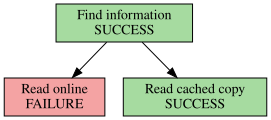

In [3]:
def selector_tick(children):
    for child in children:
        result = child.tick()
        if result is not Status.FAILURE:
            return result
    return Status.FAILURE

network = {"online": False}

def make_tree():
    return Selector("Find information", [
        Action("Read online", lambda: Status.SUCCESS if network["online"] else Status.FAILURE),
        Action("Read cached copy", lambda: Status.SUCCESS),
    ])

root = make_tree()
trace(root, 1)
assert root.status is Status.SUCCESS
display(diagram(root))

## Step-by-step implementation
Compare the stopping rules: sequence stops on **not SUCCESS**; selector stops on
**not FAILURE**. RUNNING stops both. A selector does not launch every alternative
at once. Its ordering is part of the policy, not an implementation detail.

    def tick(self):
        start = self.index if self.memory and self.status is Status.RUNNING else 0
        for index in range(start, len(self.children)):
            result = self.children[index].tick()
            if result is not Status.FAILURE:
                for child in self.children[index + 1:]:
                    child.reset()
                self.index, self.status = index, result
                return result
        self.status = Status.FAILURE
        return self.status

1 Find information: SUCCESS | Read online: SUCCESS | Read cached copy: INVALID


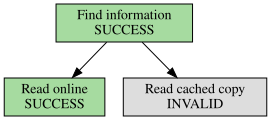

In [4]:
import inspect
print(inspect.getsource(Selector.tick))
network["online"] = True
trace(root, 1)
assert root.children[1].status is Status.INVALID
display(diagram(root))

## Interactive demonstration

In [5]:
import ipywidgets as widgets

@widgets.interact(online=False)
def choose(online=False):
    network["online"] = online
    tree = make_tree()
    trace(tree, 1)
    display(diagram(tree))

interactive(children=(Checkbox(value=False, description='online'), Output()), _dom_classes=('widget-interact',…

## Key observations

Failure can mean “try the next option.” RUNNING means an option is already handling the request.

## Exercises

1. Remove the cached copy. What happens offline?
2. Make the online action RUNNING. Does the cache get ticked?

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 04).

## Summary

Sequences express requirements; selectors express alternatives. Both propagate results upward and requests downward.